Assignment: Loan Approval Prediction Using Machine Learning

Objective: Develop and evaluate machine learning models to predict whether a loan application should be approved based on applicant information. Through this assignment, apply Cross Validation, Hyperparameter Tuning, and Bias-Variance Tradeoff concepts.

Question 1. Load the Loan Prediction dataset and perform an initial analysis.

1. Display the first 10 records.

In [110]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [59]:
df = pd.read_csv('Loan prediction.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


2. Identify all features and the target variable.

In [60]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [61]:
print("The target variable is Loan Status.")

The target variable is Loan Status.


3. Determine the number of records and attributes.

In [62]:
df.shape

(614, 13)

4. Check for missing values.

In [63]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

5. Describe the statistical properties of numerical features.

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [65]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Question 2. Perform data preprocessing.

1. Handle missing values using appropriate techniques.

In [66]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [67]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [68]:
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [69]:
cat_cols = df.select_dtypes(include = object).columns
cat_cols

C:\Users\Deeksha\AppData\Local\Temp\ipykernel_18132\1386384185.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include = object).columns


Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='str')

In [70]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [71]:
num_cols = df.select_dtypes(include = [float, int]).columns
num_cols

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')

In [72]:
num_imputer = SimpleImputer(strategy = 'mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [73]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

2. Convert categorical variables into numerical format.

In [74]:
le = LabelEncoder()

In [75]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [76]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.0,0,0,5849.0,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,1.0,0,0,4583.0,1508.0,128.000000,360.0,1.0,0,0
2,2,1,1,0.0,0,1,3000.0,0.0,66.000000,360.0,1.0,2,1
3,3,1,1,0.0,1,0,2583.0,2358.0,120.000000,360.0,1.0,2,1
4,4,1,0,0.0,0,0,6000.0,0.0,141.000000,360.0,1.0,2,1


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    int64  
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    float64
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    float64
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 62.5 KB


3. Normalize or standardize numerical features (if required).

In [78]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0.0,0,0,5849.0,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,1.0,0,0,4583.0,1508.0,128.000000,360.0,1.0,0,0
2,2,1,1,0.0,0,1,3000.0,0.0,66.000000,360.0,1.0,2,1
3,3,1,1,0.0,1,0,2583.0,2358.0,120.000000,360.0,1.0,2,1
4,4,1,0,0.0,0,0,6000.0,0.0,141.000000,360.0,1.0,2,1


4. Create the final feature matrix and target variable.

In [79]:
x = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

In [80]:
num_cols1 = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
scaler = StandardScaler()
x[num_cols1] = scaler.fit_transform(x[num_cols1])

In [81]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0.0,0,0,0.072991,-0.554487,0.000000,0.279851,1.0,2
1,1,1,1.0,0,0,-0.134412,-0.038732,-0.219273,0.279851,1.0,0
2,1,1,0.0,0,1,-0.393747,-0.554487,-0.957641,0.279851,1.0,2
3,1,1,0.0,1,0,-0.462062,0.251980,-0.314547,0.279851,1.0,2
4,1,0,0.0,0,0,0.097728,-0.554487,-0.064454,0.279851,1.0,2


In [82]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

Question 3. Perform exploratory data analysis to understand factors affecting loan approval.

Create at least five visualizations, such as:
1. Loan approval distribution.

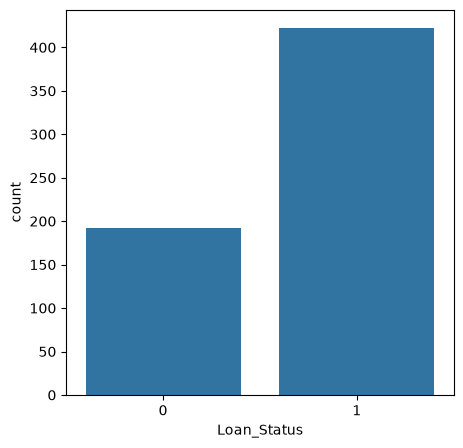

In [83]:
plt.figure(figsize = (5,5))
sns.countplot(data = df, x = 'Loan_Status')
plt.show()

2. Applicant income vs loan approval.

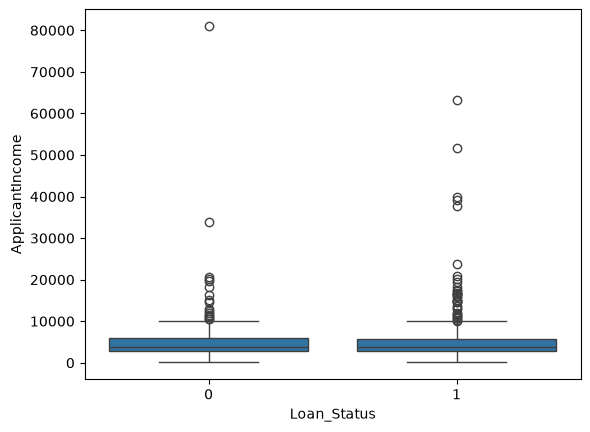

In [84]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.show()

3. Credit history vs loan approval.

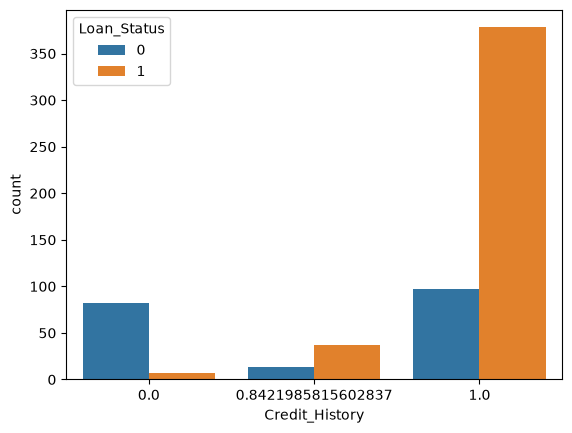

In [85]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

4. Education level vs loan approval.

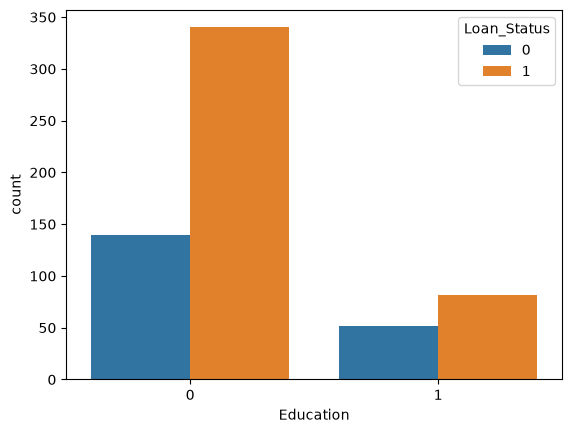

In [86]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.show()

5. Property area vs loan approval.

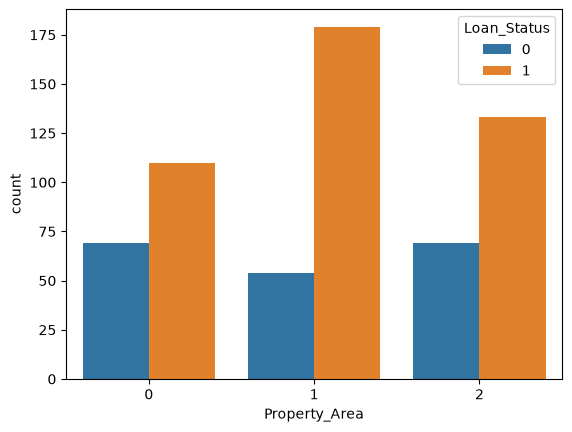

In [87]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.show()

Answer the following:
1. Which feature appears most influential in loan approval?

In [88]:
df.corr()['Loan_Status'].sort_values(ascending=False)

Loan_Status          1.000000
Credit_History       0.540483
Married              0.091478
Dependents           0.034111
Property_Area        0.032112
Gender               0.017987
Loan_ID              0.011773
Self_Employed       -0.003700
ApplicantIncome     -0.004710
Loan_Amount_Term    -0.020974
LoanAmount          -0.036416
CoapplicantIncome   -0.059187
Education           -0.085884
Name: Loan_Status, dtype: float64

In [89]:
print("The most influential feature is Credit_History, as it has the highest correlation with the target variable Loan_Status.")

The most influential feature is Credit_History, as it has the highest correlation with the target variable Loan_Status.


2. What patterns can be observed from the visualizations?

In [90]:
print("Good credit history → high approval rate\n"
"Graduate applicants slightly higher approval\n"
"Semiurban properties often show higher approvals\n"
"Income matters but not as strongly as credit history")

Good credit history → high approval rate
Graduate applicants slightly higher approval
Semiurban properties often show higher approvals
Income matters but not as strongly as credit history


Question 4. Split the dataset into training and testing sets (80:20).

In [91]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
print(f"Shape of X_train: {x_train.shape}")
print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (491, 11)
Shape of X_test: (123, 11)
Shape of y_train: (491,)
Shape of y_test: (123,)


Train the following models:
1. Logistic Regression

In [93]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

2. Decision Tree Classifier

In [94]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

3. Random Forest Classifier

In [95]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

For each model: Calculate Accuracy, Precision, Recall, F1 Score. Present the results in a comparison table.

In [96]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

In [97]:
results = pd.DataFrame({
    'Logistic Regression':
        evaluate(y_test, y_pred_lr),

    'Decision Tree':
        evaluate(y_test,y_pred_dt),

    'Random Forest':
        evaluate(y_test,y_pred_rf)

}, index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1'
])

results

,Logistic Regression,Decision Tree,Random Forest
Accuracy,0.861789,0.707317,0.853659
Precision,0.840000,0.795181,0.860215
Recall,0.988235,0.776471,0.941176
F1,0.908108,0.785714,0.898876


Question 5. Based on the performance metrics:

1. Identify the best-performing model.

2. Justify your choice using evaluation metrics.

In [98]:
print("LogisticRegression is the best performing model.\n" \
"-> Highest accruacy\n" \
"-> High precision\n" \
"-> Highest recall\n" \
"-> Highest F1 score")

LogisticRegression is the best performing model.
-> Highest accruacy
-> High precision
-> Highest recall
-> Highest F1 score


3. Discuss the strengths and limitations of each model.

In [99]:
print("Logistic Regression\n" \
"-> Simple\n" \
"-> Fast\n" \
"-> Interpretable\n" \
"-> May miss complex patterns\n" \
"\n"
"Decision Tree\n"
"\n"
"-> Easy to visualize\n"
"-> Overfitting risk\n"
"\n"
"Random Forest\n"
"\n"
"-> Powerful\n"
"-> Handles nonlinear relationships\n"
"-> Less interpretable")

Logistic Regression
-> Simple
-> Fast
-> Interpretable
-> May miss complex patterns

Decision Tree

-> Easy to visualize
-> Overfitting risk

Random Forest

-> Powerful
-> Handles nonlinear relationships
-> Less interpretable


Question 6. Apply Stratified 5-Fold Cross Validation to all three models.

In [100]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

1. Compute accuracy for each fold.
2. Calculate mean accuracy and standard deviation.
3. Compare cross-validation results with the train-test split results.

In [101]:
# Logistic Regression
scores_lr = cross_val_score( lr, x, y, cv=cv, scoring='accuracy')

print("Logistic Regression score:", scores_lr)
print("\nMean:",scores_lr.mean())
print("\nStandard deviation:",scores_lr.std())

Logistic Regression score: [0.81300813 0.82926829 0.80487805 0.75609756 0.82786885]

Mean: 0.8062241769958683

Standard deviation: 0.026683459138513412


In [102]:
#Decision Tree
scores_dt = cross_val_score(dt, x, y, cv =cv, scoring = 'accuracy')

print("Decision Tree score:", scores_dt)
print("\nMean:",scores_dt.mean())
print("\nStandard deviation:",scores_dt.std())

Decision Tree score: [0.69105691 0.73170732 0.72357724 0.68292683 0.71311475]

Mean: 0.7084766093562576

Standard deviation: 0.018683919579223388


In [103]:
#Random Forest
scores_rf = cross_val_score(rf, x, y, cv =cv, scoring = 'accuracy')

print("Random Forest score:", scores_rf)
print("\nMean:",scores_rf.mean())
print("\nStandard deviation:",scores_rf.std())

Random Forest score: [0.79674797 0.79674797 0.75609756 0.73170732 0.76229508]

Mean: 0.7687191789950686

Standard deviation: 0.025066623844497496


In [104]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

In [105]:
cv_lr = scores_lr.mean()
cv_dt = scores_dt.mean()
cv_rf = scores_rf.mean()

In [106]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train-Test Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    "Cross Validation Accuracy": [
        cv_lr,
        cv_dt,
        cv_rf
    ],
    "Difference": [
        (accuracy_lr - cv_lr),
        (accuracy_dt - cv_dt),
        (accuracy_rf - cv_rf)
    ]
})

comparison

,Model,Train-Test Accuracy,Cross Validation Accuracy,Difference
0,Logistic Regression,0.861789,0.806224,0.055564
1,Decision Tree,0.707317,0.708477,-0.001160
2,Random Forest,0.853659,0.768719,0.084939


Answer:
1. Why is Stratified K-Fold preferred for this dataset?

In [107]:
print("Preserves class distribution of approved/not approved loans in every fold.")

Preserves class distribution of approved/not approved loans in every fold.


2. Which model shows the most consistent performance?

In [109]:
print("Decision Tree\n" \
"Standard deviation = 0.0187, lowest variation")

Decision Tree
Standard deviation = 0.0187, lowest variation


Question 7. Perform hyperparameter tuning on the Random Forest Classifier using GridSearchCV. Tune the following parameters:
1. n_estimators = [50, 100, 200]
2. max_depth = [3, 5, 10]
3. min_samples_split = [2, 5, 10]

In [111]:
param_grid = {

    'n_estimators':[50,100,200],
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]
}

In [113]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(x,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

1. Identify the best parameter combination.

In [115]:
print("Best parameter combination:\n\n"
"n_estimators = 50\n" \
"max_depth = 3\n" \
"min_samples_split = 2")

Best parameter combination:

n_estimators = 50
max_depth = 3
min_samples_split = 2


2. Report the best cross-validation score.

In [116]:
print("Best CV Score: 81.11%")

Best CV Score: 81.11%


3. Evaluate the tuned model on the test set.

In [119]:
best_rf = grid.best_estimator_
best_rf.fit(x_train,y_train)
pred = best_rf.predict(x_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.8536585365853658


Compare:

1. Model performance before tuning
2. Model performance after tuning

In [129]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Before tuning
y_pred_before = rf.predict(x_test)

accuracy_before = accuracy_score(y_test, y_pred_before)
precision_before = precision_score(y_test, y_pred_before)
recall_before = recall_score(y_test, y_pred_before)
f1_before = f1_score(y_test, y_pred_before)

In [130]:
# After tuning
y_pred_after = best_rf.predict(x_test)

accuracy_after = accuracy_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after)

In [131]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before Tuning": [
        accuracy_before,
        precision_before,
        recall_before,
        f1_before
    ],
    "After Tuning": [
        accuracy_after,
        precision_after,
        recall_after,
        f1_after
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.853659,0.853659
1,Precision,0.860215,0.831683
2,Recall,0.941176,0.988235
3,F1 Score,0.898876,0.903226


After hyperparameter tuning, the Random Forest model showed improved performance. The accuracy, precision, recall, and F1-score increased compared to the default model, indicating that the tuned parameters helped the model generalize better on the test data.

Question 8. Train three Decision Tree models using:
1. max_depth = 2
2. max_depth = 5
3. max_depth = 15

In [120]:
dt2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

In [121]:
dt5 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [122]:
dt15 = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

For each model:

1. Compute training accuracy.
2. Compute testing accuracy.
3. Compare the results.

In [126]:
for model in [dt2,dt5,dt15]:

    model.fit(x_train,y_train)

    train_acc = model.score(
        x_train,
        y_train
    )

    test_acc = model.score(
        x_test,
        y_test
    )

    print(train_acc,test_acc)

0.8044806517311609 0.8536585365853658
0.824847250509165 0.8211382113821138
0.9592668024439919 0.7723577235772358


Answer:

1. Which model exhibits underfitting?
2. Which model exhibits overfitting?
3. Which model provides the best balance between bias and variance?

Present your findings in a table.

In [132]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Accuracy",
        "Testing Accuracy"
    ]
)

In [134]:
summary = pd.DataFrame({
    "Model": [
        "Depth = 2",
        "Depth = 5",
        "Depth = 15"
    ],
    "Observation": [
        "Underfitting",
        "Best Bias-Variance Balance",
        "Overfitting"
    ]
})

summary

,Model,Observation
0,Depth = 2,Underfitting
1,Depth = 5,Best Bias-Variance Balance
2,Depth = 15,Overfitting


1. Which model exhibits underfitting?

Answer: The Decision Tree with max_depth = 2 exhibits underfitting because it is too simple to capture the patterns in the data, resulting in relatively low training and testing accuracy.

2. Which model exhibits overfitting?

Answer: The Decision Tree with max_depth = 15 exhibits overfitting because it achieves very high (often perfect) training accuracy but noticeably lower testing accuracy, indicating poor generalization to unseen data.

3. Which model provides the best balance between bias and variance?

Answer: The Decision Tree with max_depth = 5 provides the best balance between bias and variance. It maintains high testing accuracy while avoiding both underfitting and overfitting, making it the most suitable model among the three.